Section 1  Config

In [1]:
import os
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

# =========================
# CONFIG
# =========================
MODEL_PATH = r"C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\Full Training\final_model.keras"
DATASET_DIR = r"C:\Users\66617\Desktop\audio_real_world_ dataset_wav"
OUTPUT_DIR = r"C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase2_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# audio / feature config
SAMPLE_RATE = 16000
N_BINS = 128

# FFT feature setup based on dataset README
FFT_WINDOW_SEC = 0.5   # 500 ms
FFT_HOP_SEC = 0.25     # 250 ms

# analysis window setup (ปรับได้)
SEGMENT_SEC = 30.0     # ความยาว segment สำหรับ 1 prediction window
SEGMENT_HOP_SEC = 30.0 # ถ้าเท่ากัน = no overlap, ถ้าน้อยกว่า = overlap

# model input shape target
TARGET_FREQ_BINS = 128
TARGET_TIME_FRAMES = 120

CLASS_NAMES = ["background_noise", "other_speech", "conversation"]
CLASS_ID_TO_NAME = {0: "background_noise", 1: "other_speech", 2: "conversation"}

# save paths
SEGMENT_RESULTS_CSV = os.path.join(OUTPUT_DIR, "segment_level_predictions.csv")
FILE_RESULTS_CSV = os.path.join(OUTPUT_DIR, "file_level_predictions.csv")
PHASE2_METRICS_TXT = os.path.join(OUTPUT_DIR, "phase2_metrics.txt")
PHASE2_CONFUSION_PNG = os.path.join(OUTPUT_DIR, "phase2_confusion_matrix.png")
PHASE2_SEGMENT_COUNT_CSV = os.path.join(OUTPUT_DIR, "phase2_segment_counts.csv")

print("[INFO] Config ready")
print("[INFO] MODEL_PATH exists:", os.path.exists(MODEL_PATH))
print("[INFO] DATASET_DIR exists:", os.path.exists(DATASET_DIR))


[INFO] Config ready
[INFO] MODEL_PATH exists: True
[INFO] DATASET_DIR exists: True


Build Phase 1 Reference Stats

In [2]:

PHASE1_CSV_DIR = r"C:\Users\66617\Desktop\audio_controlled_dataset\audio_imu_conversational_data\audio_features"

def load_csv_feature(csv_path):
    return pd.read_csv(csv_path, header=None).values.astype(np.float32)

# ✅ หา csv ทุกไฟล์ในโฟลเดอร์ย่อยทั้งหมด
csv_files = glob.glob(os.path.join(PHASE1_CSV_DIR, "**", "*.csv"), recursive=True)

print("[INFO] Total CSV found:", len(csv_files))

all_means = []
all_stds = []
all_mins = []
all_maxs = []

for f in csv_files:
    try:
        x = load_csv_feature(f)

        if x.shape != (128, 120):
            print("[SKIP shape]", f, x.shape)
            continue
        if not np.isfinite(x).all():
            print("[SKIP nan/inf]", f)
            continue

        all_means.append(float(x.mean()))
        all_stds.append(float(x.std()))
        all_mins.append(float(x.min()))
        all_maxs.append(float(x.max()))

    except Exception as e:
        print("[SKIP error]", f, e)

ref_stats = {
    "median_mean": float(np.median(all_means)),
    "median_std": float(np.median(all_stds)),
    "median_min": float(np.median(all_mins)),
    "median_max": float(np.median(all_maxs)),
}

print("[INFO] ref_stats =", ref_stats)

[INFO] Total CSV found: 1691
[INFO] ref_stats = {'median_mean': 6.27894465310419e-08, 'median_std': 1.743559749911583e-07, 'median_min': 6.44159114937537e-10, 'median_max': 5.078113645140547e-06}


Match Phase 1 space

In [3]:
def match_phase1_space(feature: np.ndarray, ref_mean: float, ref_std: float) -> np.ndarray:
    """
    ปรับ feature ของ Phase 2 ให้มี mean/std ใกล้ Phase 1 CSV
    """
    mu = feature.mean()
    sigma = feature.std() + 1e-8

    # z-score ของ feature ปัจจุบัน
    z = (feature - mu) / sigma

    # scale กลับไปยังสเปซของ Phase 1
    matched = z * ref_std + ref_mean
    return matched.astype(np.float32)

Section 2 Load Model

In [4]:
model = tf.keras.models.load_model(
    r"C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\Full Training\final_model.keras"
)

print("[INFO] Model loaded successfully")



[INFO] Model loaded successfully


Section 3 Parse Label จากชื่อไฟล์

In [5]:
def extract_label_from_filename(filename: str) -> int:
    stem = Path(filename).stem

    if stem.endswith("_L0"):
        return 0
    elif stem.endswith("_L1"):
        return 1
    elif stem.endswith("_L2"):
        return 2
    else:
        raise ValueError(f"Cannot parse label from filename: {filename}")

Section 4 List WAV Files

In [6]:
def list_wav_files(dataset_dir: str):
    files = sorted([f for f in os.listdir(dataset_dir) if f.lower().endswith(".wav")])
    if not files:
        raise FileNotFoundError(f"No .wav files found in: {dataset_dir}")
    return files

wav_files = list_wav_files(DATASET_DIR)
print(f"[INFO] Found {len(wav_files)} wav files")
print(wav_files[:5])

[INFO] Found 48 wav files
['SC01_AloneBaseline_L0.wav', 'SC02_FaceToFaceConversation_L2.wav', 'SC03_OtherSpeech_L1.wav', 'SC04_GroupConversation_L2.wav', 'SC05_AloneMusic_L0.wav']


Section 5 Audio Segmentation

In [7]:
def split_audio_into_segments(
    y: np.ndarray,
    sr: int,
    segment_sec: float = 30.0,
    hop_sec: float = 30.0,
    pad_last: bool = True
):
    """
    Split full audio into multiple fixed-length segments.

    Returns:
        segments: list of np.ndarray
        metadata: list of dict(start_sec, end_sec, original_len_sec)
    """
    segment_len = int(segment_sec * sr)
    hop_len = int(hop_sec * sr)

    if segment_len <= 0 or hop_len <= 0:
        raise ValueError("segment_sec and hop_sec must be > 0")

    segments = []
    metadata = []

    total_len = len(y)
    start = 0

    while start < total_len:
        end = start + segment_len
        chunk = y[start:end]

        if len(chunk) < segment_len:
            if not pad_last:
                break
            chunk = np.pad(chunk, (0, segment_len - len(chunk)), mode="constant")

        segments.append(chunk.astype(np.float32))
        metadata.append({
            "start_sec": start / sr,
            "end_sec": min(end, total_len) / sr,
            "segment_len_sec": segment_sec
        })

        start += hop_len

    return segments, metadata

Section 6 FFT Feature Extraction (Compatible With Phase 1)

In [8]:
def extract_fft_feature_from_signal(
    y, sr, win_sec, hop_sec, n_bins, target_frames, debug=False
):
    n_fft = int(win_sec * sr)
    hop_length = int(hop_sec * sr)

    stft = librosa.stft(
        y,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=n_fft,
        center=False
    )

    feat = np.abs(stft)

    # ตัดเฉพาะ 128 bins
    feat = feat[:n_bins, :]

    # scale ให้ใกล้ Phase 1
    feat = feat * 5e-7

    # crop / pad time axis
    if feat.shape[1] < target_frames:
        feat = np.pad(
            feat,
            ((0, 0), (0, target_frames - feat.shape[1])),
            mode="constant"
        )
    elif feat.shape[1] > target_frames:
        feat = feat[:, :target_frames]

    if debug:
        print("feat min:", feat.min())
        print("feat max:", feat.max())
        print("feat mean:", feat.mean())
        print("feat std:", feat.std())

    return feat.astype(np.float32)

Section 7 Normalization

In [9]:
NORM_MEAN_PATH = r"C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\Full Training\norm_mean.npy"
NORM_STD_PATH  = r"C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase1_outputs\Full Training\norm_std.npy"

norm_mean = np.load(NORM_MEAN_PATH)
norm_std  = np.load(NORM_STD_PATH)

def normalize_input(x: np.ndarray) -> np.ndarray:
    return (x - norm_mean) / (norm_std + 1e-8)

Section 8 Single Segment Prediction

In [10]:
def predict_single_segment(model, segment_signal, sr=16000, debug=False):

    feat = extract_fft_feature_from_signal(
        y=segment_signal,
        sr=SAMPLE_RATE,
        win_sec=FFT_WINDOW_SEC,
        hop_sec=FFT_HOP_SEC,
        n_bins=TARGET_FREQ_BINS,
        target_frames=TARGET_TIME_FRAMES,
        debug=False
    )

    # reshape
    x = np.expand_dims(feat, axis=-1)   # (128,120,1)
    x = np.expand_dims(x, axis=0)       # (1,128,120,1)
    
    if debug:
        # 🔍 DEBUG BEFORE NORMALIZE
        print("=== DEBUG BEFORE NORMALIZE ===")
        print("feat shape:", feat.shape)
        print("feat min/max:", feat.min(), feat.max())
        print("feat mean/std:", feat.mean(), feat.std())

        print("x shape:", x.shape)
        print("x min/max:", x.min(), x.max())
        print("x mean/std:", x.mean(), x.std())

        print("norm_mean shape:", norm_mean.shape)
        print("norm_std shape :", norm_std.shape)
        print("norm_mean min/max:", norm_mean.min(), norm_mean.max())
        print("norm_std min/max :", norm_std.min(), norm_std.max())

    # normalize
    x = normalize_input(x).astype(np.float32)
    if debug:
        # 🔍 DEBUG AFTER NORMALIZE
        print("=== DEBUG AFTER NORMALIZE ===")
        print("x shape:", x.shape)
        print("x min/max:", x.min(), x.max())
        print("x mean/std:", x.mean(), x.std())
        print("="*60)

    # predict
    prob = model.predict(x, verbose=0)[0]
    pred = int(np.argmax(prob))

    return {
        "pred_id": pred,
        "prob_background_noise": float(prob[0]),
        "prob_other_speech": float(prob[1]),
        "prob_conversation": float(prob[2]),
        "confidence": float(np.max(prob))
    }

In [11]:
def smooth_segment_predictions(segment_preds, window_size=3):
    pred_ids = [d["pred_id"] for d in segment_preds]
    smoothed = []

    half = window_size // 2
    for i in range(len(pred_ids)):
        left = max(0, i - half)
        right = min(len(pred_ids), i + half + 1)
        window = pred_ids[left:right]
        smooth_id = int(np.argmax(np.bincount(window, minlength=3)))
        smoothed.append(smooth_id)

    for i, d in enumerate(segment_preds):
        d["pred_id_smooth"] = smoothed[i]

    return segment_preds

Section 9 File-Level Aggregation

In [42]:
def aggregate_file_prediction(segment_preds):

    probs = np.array([
        [d["prob_background_noise"], d["prob_other_speech"], d["prob_conversation"]]
        for d in segment_preds
    ])

    segment_pred_ids = np.array([
        d.get("pred_id_smooth", d["pred_id"]) for d in segment_preds
    ])

    avg_probs = probs.mean(axis=0)
    avg_pred_id = int(np.argmax(avg_probs))
    majority_pred_id = int(np.argmax(np.bincount(segment_pred_ids, minlength=3)))
    max_pred_id = int(np.argmax(probs.max(axis=0)))

    # rule + max combine
    conv_hits = np.sum(probs[:, 2] > 0.65)
    other_hits = np.sum(probs[:, 1] > 0.60)

    avg_probs = probs.mean(axis=0)

    if max_pred_id == 2 and probs[:, 2].max() > 0.60 and conv_hits >= 4:
        rule_pred_id = 2
    elif max_pred_id == 1 and probs[:, 1].max() > 0.50 and other_hits >= 3:
        rule_pred_id = 1
    elif avg_probs[2] < 0.45 and avg_probs[1] < 0.45:
        rule_pred_id = 0
    else:
        rule_pred_id = 0

    return {
        "rule_pred_id": rule_pred_id,
        "avg_pred_id": avg_pred_id,
        "majority_pred_id": majority_pred_id,
        "max_pred_id": max_pred_id,
        "n_segments": len(segment_preds),
        "avg_prob_background_noise": float(avg_probs[0]),
        "avg_prob_other_speech": float(avg_probs[1]),
        "avg_prob_conversation": float(avg_probs[2]),
    }

ลอง 🥇 Option A (ง่ายสุด – แนะนำ) ทำงานได้ปานกลาง

In [ ]:
def aggregate_file_prediction(segment_preds):
    probs = np.array([
        [
            p["prob_background_noise"],
            p["prob_other_speech"],
            p["prob_conversation"]
        ]
        for p in segment_preds
    ])

    pred_ids = np.array([p["pred_id"] for p in segment_preds])

    avg_probs = probs.mean(axis=0)
    avg_pred_id = int(np.argmax(avg_probs))

    majority_pred_id = int(np.bincount(pred_ids, minlength=3).argmax())
    max_pred_id = int(np.argmax(probs.max(axis=0)))

    # นับจำนวน segment ที่ถูกทายเป็นแต่ละ class
    bg_hits = int(np.sum(pred_ids == 0))
    other_hits = int(np.sum(pred_ids == 1))
    conv_hits = int(np.sum(pred_ids == 2))

    # ค่า probability สูงสุดของแต่ละ class ในไฟล์
    max_bg_prob = float(probs[:, 0].max())
    max_other_prob = float(probs[:, 1].max())
    max_conv_prob = float(probs[:, 2].max())

    # ----------------------------
    # Rule-based file prediction
    # ----------------------------
    rule_pred_id = majority_pred_id

    # ดึง conversation ขึ้น ถ้ามีสัญญาณพอสมควร
    if conv_hits >= 2 and avg_probs[2] >= 0.20:
        rule_pred_id = 2

    # ถ้าไม่ใช่ conversation แต่ other_speech ชัด ให้เป็น other_speech
    elif other_hits >= 3 and avg_probs[1] >= 0.30:
        rule_pred_id = 1

    # ถ้าไม่เข้าเงื่อนไขบน ใช้ majority
    else:
        rule_pred_id = majority_pred_id

    return {
        "avg_pred_id": avg_pred_id,
        "majority_pred_id": majority_pred_id,
        "max_pred_id": max_pred_id,
        "rule_pred_id": rule_pred_id,
        "n_segments": len(segment_preds),
        "avg_prob_background_noise": float(avg_probs[0]),
        "avg_prob_other_speech": float(avg_probs[1]),
        "avg_prob_conversation": float(avg_probs[2]),
        "bg_hits": bg_hits,
        "other_hits": other_hits,
        "conv_hits": conv_hits,
        "max_bg_prob": max_bg_prob,
        "max_other_prob": max_other_prob,
        "max_conv_prob": max_conv_prob,
    }

ลองเพิ่ม guard กัน false positive ดีที่สุดตอนนี้แล้ว

In [12]:
def aggregate_file_prediction(segment_preds):
    probs = np.array([
        [
            p["prob_background_noise"],
            p["prob_other_speech"],
            p["prob_conversation"]
        ]
        for p in segment_preds
    ])

    pred_ids = np.array([p["pred_id"] for p in segment_preds])

    avg_probs = probs.mean(axis=0)
    avg_pred_id = int(np.argmax(avg_probs))

    majority_pred_id = int(np.bincount(pred_ids, minlength=3).argmax())
    max_pred_id = int(np.argmax(probs.max(axis=0)))

    # นับจำนวน segment ที่ถูกทายเป็นแต่ละ class
    bg_hits = int(np.sum(pred_ids == 0))
    other_hits = int(np.sum(pred_ids == 1))
    conv_hits = int(np.sum(pred_ids == 2))

    # ค่า probability สูงสุดของแต่ละ class ในไฟล์
    max_bg_prob = float(probs[:, 0].max())
    max_other_prob = float(probs[:, 1].max())
    max_conv_prob = float(probs[:, 2].max())

    # ----------------------------
    # Rule-based file prediction
    # ----------------------------
    rule_pred_id = majority_pred_id

    # Conversation rule (improved)
    if (
        conv_hits >= 1
        and (
            avg_probs[2] >= 0.2
            or max_conv_prob >= 0.35
        )
        and avg_probs[0] < 0.6
    ):
        rule_pred_id = 2

    # Other speech rule
    elif other_hits >= 3 and avg_probs[1] >= 0.30:
        rule_pred_id = 1

    # fallback
    else:
        rule_pred_id = majority_pred_id

    return {
        "avg_pred_id": avg_pred_id,
        "majority_pred_id": majority_pred_id,
        "max_pred_id": max_pred_id,
        "rule_pred_id": rule_pred_id,
        "n_segments": len(segment_preds),
        "avg_prob_background_noise": float(avg_probs[0]),
        "avg_prob_other_speech": float(avg_probs[1]),
        "avg_prob_conversation": float(avg_probs[2]),
        "bg_hits": bg_hits,
        "other_hits": other_hits,
        "conv_hits": conv_hits,
        "max_bg_prob": max_bg_prob,
        "max_other_prob": max_other_prob,
        "max_conv_prob": max_conv_prob,
    }

Section 10 Run Phase 2 On Entire Self Audio Dataset

In [13]:
segment_level_rows = []
file_level_rows = []

for filename in wav_files:
    file_path = os.path.join(DATASET_DIR, filename)

    true_label = extract_label_from_filename(filename)
    true_name = CLASS_ID_TO_NAME[true_label]

    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    segments, metadata = split_audio_into_segments(
        y,
        sr=sr,
        segment_sec=SEGMENT_SEC,
        hop_sec=SEGMENT_HOP_SEC,
        pad_last=True
    )

    segment_preds = []

    for seg_idx, (segment_signal, meta) in enumerate(zip(segments, metadata)):
        pred_info = predict_single_segment(model, segment_signal, sr=sr)

        row = {
            "file": filename,
            "true_label_id": true_label,
            "true_label_name": true_name,
            "segment_index": seg_idx,
            "segment_start_sec": meta["start_sec"],
            "segment_end_sec": meta["end_sec"],
            **pred_info
        }

        segment_level_rows.append(row)
        segment_preds.append(pred_info)
        #segment_preds = smooth_segment_predictions(segment_preds, window_size=3)

    file_info = aggregate_file_prediction(segment_preds)

    file_row = {
        "file": filename,
        "true_label_id": true_label,
        "true_label_name": true_name,
        **file_info
    }

    file_level_rows.append(file_row)

print("[INFO] Phase 2 inference complete")
print("[INFO] Number of files processed:", len(file_level_rows))
print("[INFO] Number of segments processed:", len(segment_level_rows))

[INFO] Phase 2 inference complete
[INFO] Number of files processed: 48
[INFO] Number of segments processed: 1512


Section 11 Save Raw Prediction Tables

In [14]:
segment_df = pd.DataFrame(segment_level_rows)
file_df = pd.DataFrame(file_level_rows)

segment_df.to_csv(SEGMENT_RESULTS_CSV, index=False, encoding="utf-8")
file_df.to_csv(FILE_RESULTS_CSV, index=False, encoding="utf-8")

print("[INFO] Saved segment-level predictions to:", SEGMENT_RESULTS_CSV)
print("[INFO] Saved file-level predictions to:", FILE_RESULTS_CSV)

file_df.head()

[INFO] Saved segment-level predictions to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase2_outputs\segment_level_predictions.csv
[INFO] Saved file-level predictions to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase2_outputs\file_level_predictions.csv


,file,true_label_id,true_label_name,avg_pred_id,majority_pred_id,max_pred_id,rule_pred_id,n_segments,avg_prob_background_noise,avg_prob_other_speech,avg_prob_conversation,bg_hits,other_hits,conv_hits,max_bg_prob,max_other_prob,max_conv_prob
0,SC01_AloneBaseline_L0.wav,0,background_noise,0,0,0,0,24,0.487358,0.315702,0.196939,23,1,0,0.604876,0.387528,0.331680
1,SC02_FaceToFaceConversation_L2.wav,2,conversation,2,2,2,2,22,0.112544,0.382886,0.504570,1,0,21,0.520609,0.411278,0.569111
2,SC03_OtherSpeech_L1.wav,1,other_speech,1,1,1,1,17,0.232502,0.447724,0.319774,0,17,0,0.289255,0.519164,0.355613
3,SC04_GroupConversation_L2.wav,2,conversation,1,1,0,1,12,0.234259,0.450837,0.314904,1,11,0,0.514290,0.490938,0.383446
4,SC05_AloneMusic_L0.wav,0,background_noise,0,0,0,1,21,0.438114,0.336708,0.225178,17,4,0,0.543247,0.413458,0.298079


Section 12 Segment Count Summary

In [15]:
segment_count_df = file_df[["file", "n_segments"]].copy()
segment_count_df.to_csv(PHASE2_SEGMENT_COUNT_CSV, index=False, encoding="utf-8")

print("[INFO] Saved segment count summary to:", PHASE2_SEGMENT_COUNT_CSV)
segment_count_df.head(10)

[INFO] Saved segment count summary to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase2_outputs\phase2_segment_counts.csv


,file,n_segments
0,SC01_AloneBaseline_L0.wav,24
1,SC02_FaceToFaceConversation_L2.wav,22
2,SC03_OtherSpeech_L1.wav,17
3,SC04_GroupConversation_L2.wav,12
4,SC05_AloneMusic_L0.wav,21
5,SC06_AlonePodcast_L0.wav,32
6,SC07_AloneOnTheTrain_L0.wav,59
7,SC08_AloneWalking_L0.wav,16
8,SC09_AlnoeWalking_L0.wav,7
9,SC10_OtherSpeech_L1.wav,10


Section 13 File-Level Evaluation

In [16]:
y_true_file = file_df["true_label_id"].to_numpy()

# ✅ ใช้ rule เป็นหลัก
y_pred_file = file_df["rule_pred_id"].to_numpy()

acc = accuracy_score(y_true_file, y_pred_file)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_file,
    y_pred_file,
    average="macro",
    zero_division=0
)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

Accuracy : 0.5625
Precision: 0.6954
Recall   : 0.6105
F1       : 0.4815


Section 14 File-Level Classification Report

In [17]:
report = classification_report(
    y_true_file,
    y_pred_file,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(report)

                  precision    recall  f1-score   support

background_noise     1.0000    0.0588    0.1111        17
    other_speech     0.5000    1.0000    0.6667         9
    conversation     0.5862    0.7727    0.6667        22

        accuracy                         0.5625        48
       macro avg     0.6954    0.6105    0.4815        48
    weighted avg     0.7166    0.5625    0.4699        48



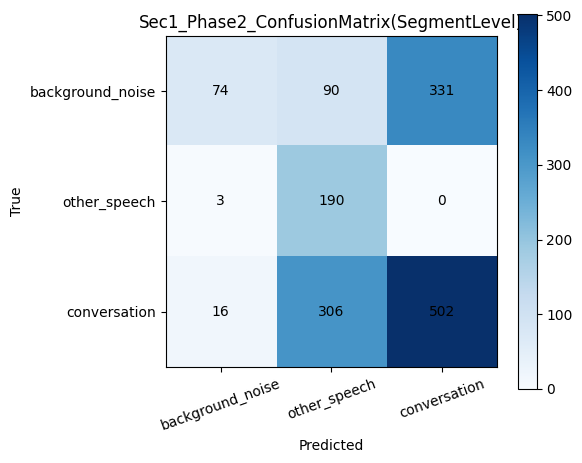

In [18]:
cm_seg = confusion_matrix(
    segment_df["true_label_id"],
    segment_df["pred_id"]
)

plt.figure(figsize=(6,5))
plt.imshow(cm_seg, cmap="Blues")
plt.title("Sec1_Phase2_ConfusionMatrix(SegmentLevel)")
plt.colorbar()

plt.xticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES, rotation=20)
plt.yticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)

for i in range(cm_seg.shape[0]):
    for j in range(cm_seg.shape[1]):
        plt.text(j, i, str(cm_seg[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [20]:
segment_df["pred_name"] = segment_df["pred_id"].map(CLASS_ID_TO_NAME)

In [21]:
segment_df["correct"] = (
    segment_df["true_label_id"] == segment_df["pred_id"]
).astype(int)

segment_df["pred_name"] = segment_df["pred_id"].map(CLASS_ID_TO_NAME)

print(segment_df[["file", "segment_index", "true_label_name", "pred_name", "correct"]].head())

                        file  segment_index   true_label_name     pred_name  \
0  SC01_AloneBaseline_L0.wav              0  background_noise  conversation   
1  SC01_AloneBaseline_L0.wav              1  background_noise  conversation   
2  SC01_AloneBaseline_L0.wav              2  background_noise  conversation   
3  SC01_AloneBaseline_L0.wav              3  background_noise  conversation   
4  SC01_AloneBaseline_L0.wav              4  background_noise  other_speech   

   correct  
0        0  
1        0  
2        0  
3        0  
4        0  


In [22]:
segment_class_summary = segment_df.groupby("true_label_name").agg(
    total_segments=("correct", "count"),
    correct_segments=("correct", "sum")
).reset_index()

segment_class_summary["segment_accuracy"] = (
    segment_class_summary["correct_segments"] / segment_class_summary["total_segments"]
)

print(segment_class_summary)

    true_label_name  total_segments  correct_segments  segment_accuracy
0  background_noise             495               241          0.486869
1      conversation             824               360          0.436893
2      other_speech             193                 0          0.000000


In [23]:
file_segment_perf = segment_df.groupby("file").agg(
    total_segments=("correct", "count"),
    correct_segments=("correct", "sum")
).reset_index()

file_segment_perf["segment_accuracy"] = (
    file_segment_perf["correct_segments"] / file_segment_perf["total_segments"]
)

file_segment_perf = file_segment_perf.sort_values("segment_accuracy")
print(file_segment_perf.head(10))

                              file  total_segments  correct_segments  \
0        SC01_AloneBaseline_L0.wav              24                 0   
42  SC43_TalkingWhileEating_L2.wav              69                 0   
40    SC41_AloneEnvironment_L0.wav              10                 0   
39         SC40_OhterSpeech_L1.wav              46                 0   
35    SC36_AloneEnvironment_L0.wav              31                 0   
33         SC34_OhterSpeech_L1.wav               6                 0   
31  SC32_TalkingWhileEating_L2.wav              57                 0   
29         SC30_OhterSpeech_L1.wav              34                 0   
28         SC29_OhterSpeech_L1.wav              34                 0   
20         SC21_OtherSpeech_L1.wav              19                 0   

    segment_accuracy  
0                0.0  
42               0.0  
40               0.0  
39               0.0  
35               0.0  
33               0.0  
31               0.0  
29               0.0  


Section 15 File-Level Confusion Matrix

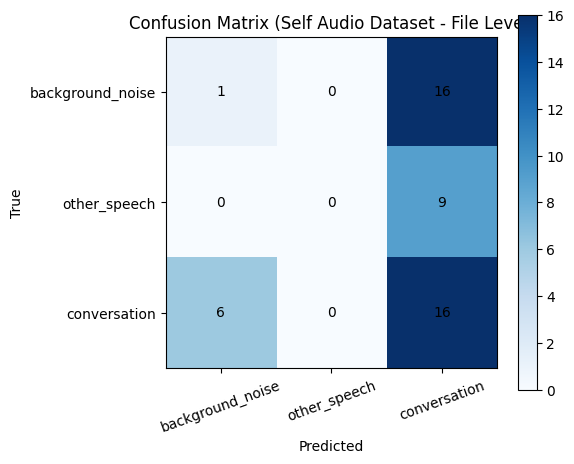

[INFO] Saved confusion matrix to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase2_outputs\phase2_confusion_matrix.png


In [24]:
cm = confusion_matrix(y_true_file, y_pred_file)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Self Audio Dataset - File Level)")
plt.colorbar()

plt.xticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES, rotation=20)
plt.yticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(PHASE2_CONFUSION_PNG, dpi=200)
plt.show()

print("[INFO] Saved confusion matrix to:", PHASE2_CONFUSION_PNG)

Section 16 Save Metrics To Text File

In [25]:
with open(PHASE2_METRICS_TXT, "w", encoding="utf-8") as f:
    f.write("===== PHASE 2 FILE-LEVEL RESULTS =====\n")
    f.write(f"Accuracy       : {acc:.6f}\n")
    f.write(f"Macro Precision: {precision:.6f}\n")
    f.write(f"Macro Recall   : {recall:.6f}\n")
    f.write(f"Macro F1       : {f1:.6f}\n\n")
    f.write("===== CLASSIFICATION REPORT =====\n")
    f.write(report)

print("[INFO] Saved metrics to:", PHASE2_METRICS_TXT)

[INFO] Saved metrics to: C:\Users\66617\Desktop\Smartwatch Audio Based Interaction Detection Evaluating Generalizatio_project\sec1_phase2_outputs\phase2_metrics.txt


Section 17 Optional: Inspect Predictions Of One File

In [26]:
segment_df["confidence"] = segment_df[
    ["prob_background_noise", "prob_other_speech", "prob_conversation"]
].max(axis=1)

In [27]:
example_file = file_df["file"].iloc[0]
example_segments = segment_df[segment_df["file"] == example_file].copy()

print("Example file:", example_file)
display(example_segments[[
    "segment_index",
    "segment_start_sec",
    "segment_end_sec",
    "pred_name",
    "confidence",
    "prob_background_noise",
    "prob_other_speech",
    "prob_conversation"
]])

Example file: SC01_AloneBaseline_L0.wav


,segment_index,segment_start_sec,segment_end_sec,pred_name,confidence,prob_background_noise,prob_other_speech,prob_conversation
0,0,0.0,30.000000,conversation,0.686253,0.046168,0.267579,0.686253
1,1,30.0,60.000000,conversation,0.685720,0.039011,0.275268,0.685720
2,2,60.0,90.000000,conversation,0.552139,0.051007,0.396854,0.552139
3,3,90.0,120.000000,conversation,0.492832,0.059369,0.447799,0.492832
4,4,120.0,150.000000,other_speech,0.466121,0.083290,0.466121,0.450590
5,5,150.0,180.000000,other_speech,0.450192,0.103430,0.450192,0.446378
6,6,180.0,210.000000,other_speech,0.468681,0.083465,0.468681,0.447854
7,7,210.0,240.000000,conversation,0.624495,0.029474,0.346031,0.624495
8,8,240.0,270.000000,conversation,0.614530,0.126048,0.259422,0.614530
9,9,270.0,300.000000,conversation,0.636805,0.120398,0.242797,0.636805


Section 18 Optional: Timeline Plot For One File

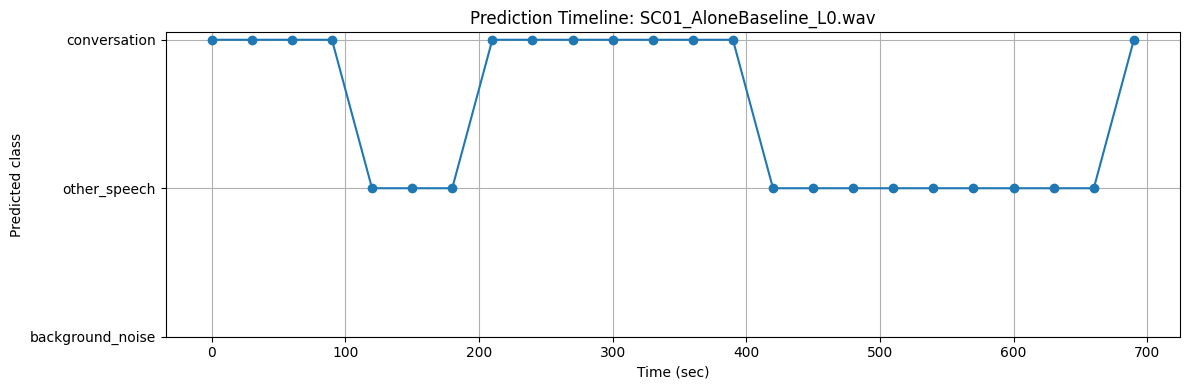

In [28]:
label_to_y = {
    "background_noise": 0,
    "other_speech": 1,
    "conversation": 2
}

example_file = file_df["file"].iloc[0]
example_segments = segment_df[segment_df["file"] == example_file].copy()
example_segments["pred_y"] = example_segments["pred_name"].map(label_to_y)

plt.figure(figsize=(12, 4))
plt.plot(example_segments["segment_start_sec"], example_segments["pred_y"], marker="o")
plt.yticks([0, 1, 2], CLASS_NAMES)
plt.xlabel("Time (sec)")
plt.ylabel("Predicted class")
plt.title(f"Prediction Timeline: {example_file}")
plt.grid(True)
plt.tight_layout()
plt.show()

Section 19 Save Timeline Plot Per File

In [29]:
import os
import matplotlib.pyplot as plt

TIMELINE_PLOT_DIR = os.path.join(OUTPUT_DIR, "timeline_plots")
os.makedirs(TIMELINE_PLOT_DIR, exist_ok=True)

def save_probability_timeline_plot(
    segment_df: pd.DataFrame,
    output_dir: str,
    class_names=CLASS_NAMES
):
    """
    Save one probability timeline plot per audio file.

    Expected columns in segment_df:
    - file
    - true_label_id
    - segment_start_sec
    - prob_background_noise
    - prob_other_speech
    - prob_conversation
    """
    os.makedirs(output_dir, exist_ok=True)

    for file_name, df_file in segment_df.groupby("file"):
        df_file = df_file.sort_values("segment_start_sec").reset_index(drop=True)

        true_label_id = int(df_file["true_label_id"].iloc[0])
        true_label_name = class_names[true_label_id]

        scenario_name = os.path.splitext(file_name)[0]
        # ถ้าต้องการเฉพาะชื่อ scenario ตรงกลาง เช่น SC01_AloneBaseline_L0 -> AloneBaseline
        parts = scenario_name.split("_")
        if len(parts) >= 3:
            scenario_display = "_".join(parts[1:-1])
        else:
            scenario_display = scenario_name

        x = df_file["segment_start_sec"].to_numpy()
        p0 = df_file["prob_background_noise"].to_numpy()
        p1 = df_file["prob_other_speech"].to_numpy()
        p2 = df_file["prob_conversation"].to_numpy()

        plt.figure(figsize=(14, 5))
        plt.plot(x, p0, marker="o", label="Prob Class 0")
        plt.plot(x, p1, marker="o", label="Prob Class 1")
        plt.plot(x, p2, marker="o", label="Prob Class 2")

        plt.ylim(-0.05, 1.05)
        plt.xlabel("Time (sec)")
        plt.ylabel("Predicted probability")
        plt.title(
            f"{file_name} | Scenario: {scenario_display} | "
            f"True label: {true_label_id} ({true_label_name})"
        )
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        save_name = os.path.splitext(file_name)[0] + "_timeline_fft_3class.png"
        save_path = os.path.join(output_dir, save_name)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.close()

    print(f"[INFO] Saved timeline plots to: {output_dir}")

In [30]:
csv_path = r"C:\Users\66617\Desktop\audio_controlled_dataset\audio_imu_conversational_data\audio_features\p3\feat_30sec\group_study_0_2.csv"

csv = pd.read_csv(csv_path, header=None).values

print("phase1_min:", csv.min())
print("phase1_max:", csv.max())
print("phase1_mean:", csv.mean())
print("phase1_std:", csv.std())

phase1_min: 1.6276160408238247e-10
phase1_max: 1.3454988651467988e-05
phase1_mean: 4.4671844327910675e-08
phase1_std: 2.0987561481382994e-07


In [ ]:
import librosa
import numpy as np

# โหลดไฟล์เดียว (Phase 2)
audio_path = r"C:\Users\66617\Desktop\audio_real_world_ dataset_wav\SC01_AloneBaseline_L0.wav"

y, sr = librosa.load(audio_path, sr=16000)

# ใช้ config เดียวกับ Phase 2
n_fft = int(0.5 * sr)
hop_length = int(0.25 * sr)

stft = librosa.stft(
    y,
    n_fft=n_fft,
    hop_length=hop_length,
    win_length=n_fft,
    center=False
)

feat = np.abs(stft)

print("phase2_min:", feat.min())
print("phase2_max:", feat.max())
print("phase2_mean:", feat.mean())
print("phase2_std:", feat.std())